# Two-Sources 1D RNN Wave Dynamics with PEC Boundaries

Solving linear system...
Total solving time:  0.6357643604278564
Prediction time:  0.0011093616485595703
Analytical solution loaded.
Prediction Finished
Relative L2 Error: 0.42%


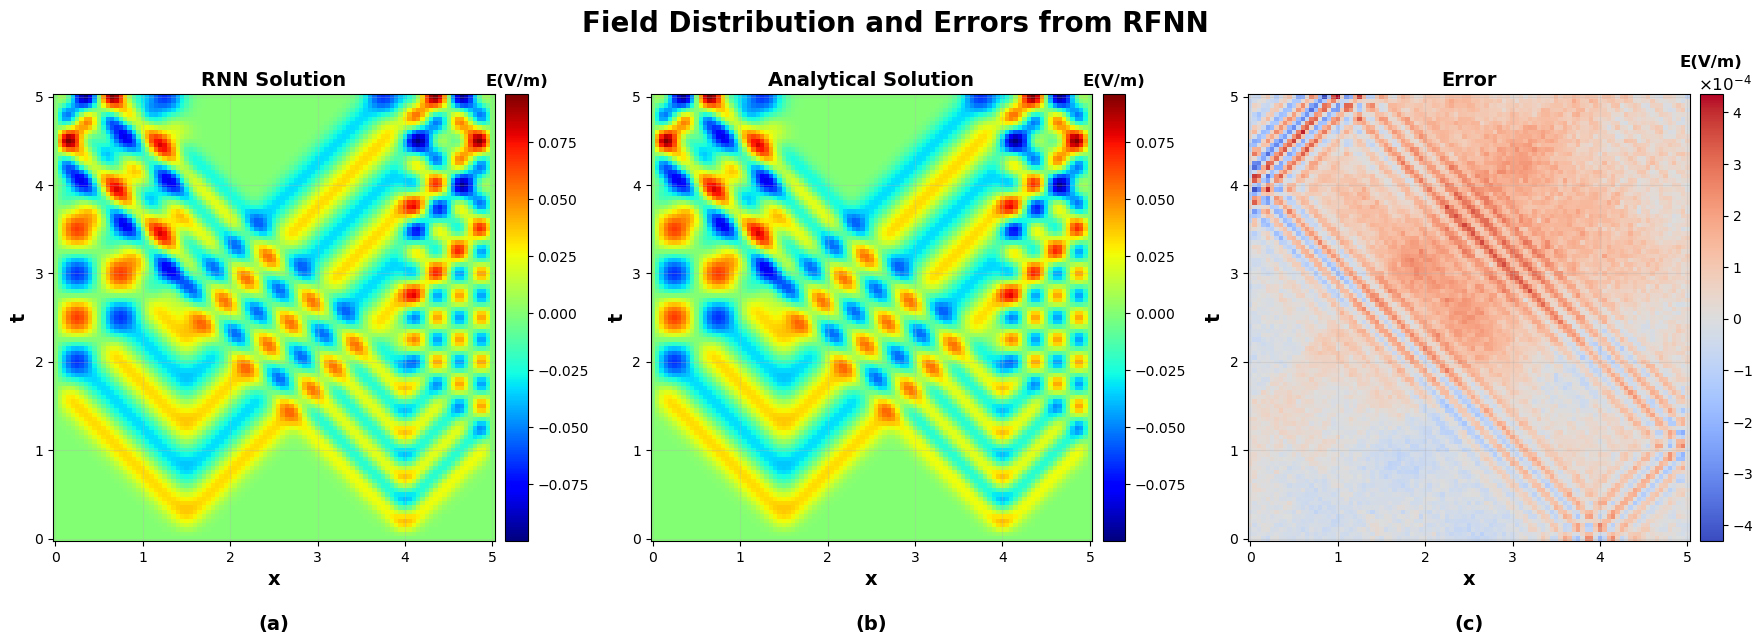

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time
from matplotlib.ticker import ScalarFormatter

# ========== Parameter Configuration ==========
initial_seed = 42  # Initial random seed for generating Ur
torch.manual_seed(initial_seed)
np.random.seed(initial_seed)  # Set initial random seed to ensure reproducibility
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

c = 1.0           # Wave speed
L = 5.0           # Spatial range [0, L]
T = 5.0           # Time range [0, T]
num_neuron = 5000 # Number of neurons (Random Features)
r_neuron = [5, 5] # Weight initialization range
d = 2             # Input dimension (t, x)

# ========== Helper Functions (Activation & Derivatives) ==========
# Tanh activation function
atv = lambda x: torch.tanh(x)
# First derivative of tanh: 1 - tanh^2(x)
diff1_atv = lambda x: 1 - torch.tanh(x) ** 2 
# Second derivative of tanh: 2 * tanh(x) * (tanh^2(x) - 1)
diff2_atv = lambda x: 2 * torch.tanh(x) * (torch.tanh(x)**2 - 1)  

# ========== Training Data Generation ==========
def generate_points():
    # Define number of collocation points for PDE, Boundary, and Initial conditions
    N_pde = 30000
    N_bnd = 20000
    N_ini = 10000
   
    # 1. PDE Residual Points (Interior of domain)
    # Uniformly sample t in [0, T] and x in [0, L]
    xi = torch.rand(N_pde, 1, device=device) * L
    ti = torch.rand(N_pde, 1, device=device) * T
    pti = torch.cat((ti, xi), dim=1) # Shape: (N_pde, 2)
    
    # 2. Boundary Condition Points (x=0 and x=L)
    tb = torch.rand(N_bnd, 1, device=device) * T
    # Left boundary (x=0)
    ptb_0 = torch.cat((tb, torch.zeros_like(tb)), dim=1)
    # Right boundary (x=L)
    ptb_L = torch.cat((tb, torch.full_like(tb, L)), dim=1)
    ptb = torch.cat((ptb_0, ptb_L), dim=0) # Combine boundaries
    
    # 3. Initial Condition Points (t=0)
    xi_ini = torch.rand(N_ini, 1, device=device) * L
    ti_ini = torch.zeros(N_ini, 1, device=device)
    pt_ini = torch.cat((ti_ini, xi_ini), dim=1)
    
    return pti, ptb, pt_ini

# ========== Physics Constraints Definition ==========
def wave_equation_residual(W, b, points, c):
    """
    Calculates the residual of the Wave Equation: u_tt - c^2 * u_xx = f
    Using automatic differentiation logic via the specific Random Feature structure.
    """
    T = points[:, 0:1]   # Time coordinate (N, 1)
    X = points[:, 1:2]   # Spatial coordinate (N, 1)
    
    # Separate weights corresponding to time and space inputs
    # W shape is (2, num_neuron). W[0] is for t, W[1] is for x
    W_t = W[0:1, :]     # Time weights (1, m)
    W_x = W[1:2, :]     # Space weights (1, m)
    
    # Calculate the feature map Z = W_t * t + W_x * x + b
    # Matrix multiplication: (N,1) @ (1,m) results in (N,m)
    Z = T @ W_t + X @ W_x + b
    
    # Calculate second derivatives using the chain rule
    # d^2/dt^2 tanh(Z) = W_t^2 * tanh''(Z)
    # We sum over the neuron dimension to aggregate contributions if necessary, 
    # but here we keep the (N, m) shape to match the linear solver structure later.
    # Note: The original code sums over dim 0, resulting in (1, m), then broadcasts.
    # To ensure matrix multiplication compatibility later, we maintain shape consistency.
    
    # Second derivative components
    phi_tt = (W_t**2) * diff2_atv(Z) # Element-wise multiplication
    phi_xx = (W_x**2) * diff2_atv(Z)

    # Return the PDE residual operator applied to the basis functions: (L_phi_tt - c^2 * L_phi_xx)
    return phi_tt - (c**2)*phi_xx  

def ini_residual(W, b, points):
    """
    Calculates the residual for the initial velocity condition: du/dt at t=0
    """
    T = points[:, 0:1]   # Time coordinate (N, 1)
    X = points[:, 1:2]   # Spatial coordinate (N, 1)
    
    # Separate weights
    W_t = W[0:1, :]     
    W_x = W[1:2, :]     
    
    # Feature map Z
    Z = T @ W_t + X @ W_x + b
    
    # First derivative with respect to time: du/dt = W_t * tanh'(Z)
    phi_t = W_t * diff1_atv(Z)
    
    return phi_t  

def u(x):
    """Analytical function for initial displacement (sin(pi*x))"""
    return torch.sin(np.pi * x).reshape(-1, 1)

# ========== Main Solver Function ==========
start_time = time.time()
L_left = 0
L_right = L
T_left = 0
T_right = T

# Source Parameters
x_src = 2.5             # Source location (unused in the actual source term below, likely legacy)
sigma = 0.1             # Standard deviation of the Gaussian source
omega = 2 * np.pi       # Angular frequency (rad/s)

x_src2 = 4.0      # Second source center position
t_peak = 1.5      # Peak time

# Initialize Weights and Biases (Random Features)
# Weights W are fixed random numbers. Only the output coefficients Ur will be solved.
W1 = torch.tensor(np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)), dtype=torch.float32)
W2 = torch.tensor(np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)), dtype=torch.float32)
W = torch.cat((W1, W2), dim=0).to(device) # Shape: (2, num_neuron)

# Initialize biases. 
# Note: The bias is subsequently modified to center the activation functions.
b1 = torch.tensor(np.random.uniform(L_left, L_right, (1, num_neuron)), dtype=torch.float32)
b2 = torch.tensor(np.random.uniform(T_left, T_right, (1, num_neuron)), dtype=torch.float32)
b = torch.cat((b1, b2), dim=0).to(device)

# Bias Correction: 
# This step shifts the bias so that the random features are centered relative to the weights.
# b_new = - sum(b_old * W). This is a specific initialization strategy for RFM.
b = -torch.sum(b * W, dim=0)

# Generate Training Points
pti, ptb, pt_ini = generate_points()

# ========== Construct Constraint Matrices (The "A" Matrix) ==========
# We are building a linear system A * Ur = F, where Ur are the unknown output weights.

# 1. PDE Residual Matrix (Interior points)
# Shape: (N_pde, num_neuron)
A_pde = wave_equation_residual(W, b, pti, c)

# 2. Boundary Condition Matrix (Dirichlet: u=0)
# Shape: (2*N_bnd, num_neuron)
A_bnd = atv(ptb @ W + b)  

# 3. Initial Condition Matrix 1 (Displacement: u(x,0)=0)
# Shape: (N_ini, num_neuron)
A_ini1 = atv(pt_ini @ W + b)  

# 4. Initial Condition Matrix 2 (Velocity: du/dt(x,0)=0)
# Shape: (N_ini, num_neuron)
A_ini2 = ini_residual(W, b, pt_ini) 

# Penalty weights for the loss function (Least Squares weighting)
p_pde = 1
p_bnd = 10
p_ini = 10

# Assemble the Global Matrix A by stacking vertically
# Total Rows: N_pde + 2*N_bnd + 2*N_ini
# Total Columns: num_neuron
A = torch.cat([p_pde*A_pde, p_bnd*A_bnd, p_ini*A_ini1, p_ini*A_ini2], dim=0)
        
# ========== Construct Target Vector (The "F" Vector) ==========
# PDE Target: Source Term f(x,t)
F_pde = torch.zeros_like(pti[:, 0:1])

# Define Source Term 1: Gaussian modulated cosine
source_term1 = 2 * torch.cos(omega * pti[:, 0:1]) * torch.exp(-((pti[:, 1:2] - 1.5)**2) / (2*sigma**2))
# Define Source Term 2: Higher frequency Gaussian modulated cosine
source_term2 = 5 * torch.cos(2 * omega * pti[:, 0:1]) * torch.exp(-((pti[:, 1:2] - 4.0)**2) / (2*sigma**2))

F_pde += source_term1 + source_term2

# Boundary and Initial Targets (Homogeneous conditions = 0)
F_bnd = torch.zeros_like(ptb[:, 0:1])
F_ini1 = torch.zeros_like(pt_ini[:, 0:1])
F_ini2 = torch.zeros_like(pt_ini[:, 0:1])

# Assemble Global Target Vector F
F = torch.cat([p_pde*F_pde, p_bnd*F_bnd, p_ini*F_ini1, p_ini*F_ini2], dim=0)

# ========== Least Squares Solver ==========
# Solve the overdetermined system A * Ur = F for Ur
# torch.linalg.lstsq computes the minimum-norm solution.
print("Solving linear system...")
Ur = torch.linalg.lstsq(A, F)[0]

end_time = time.time()
print('Total solving time: ', end_time-start_time)

# ========== Prediction and Visualization ==========
start_time = time.time()

# Create a grid for testing/visualization
t_test = torch.linspace(0, T, 101, device=device)
x_test = torch.linspace(0, L, 101, device=device)
T_mesh, X = torch.meshgrid(t_test, x_test)

# Flatten grid for batch processing
test_points = torch.cat((T_mesh.reshape(-1, 1), X.reshape(-1, 1)), dim=1)

# Predict Solution: u(x,t) = sum( Ur_i * tanh(W_i * [t,x] + b_i) )
Z_test = test_points @ W + b
u_pred = (atv(Z_test) @ Ur).reshape(X.shape)

end_time = time.time()
print('Prediction time: ', end_time-start_time)

# Load and prepare analytical solution for comparison (if available)
try:
    u_analytical = np.load('1d_fdtd_two_sources_cos_1e-4.npy')
    # Downsample to match the prediction grid size (101x101) assuming original is finer
    u_analytical = u_analytical[0::5,0::5]
    print("Analytical solution loaded.")
except FileNotFoundError:
    print("Analytical solution file not found. Skipping comparison.")

print('Prediction Finished')

# ========== Visualization ==========
plt.figure(figsize=(18, 6.6))

# 1. Predicted Solution Plot
plt.subplot(1, 3, 1)
# Create a pseudocolor plot for the RNN prediction
im_pred = plt.pcolormesh(X.cpu().numpy(), T_mesh.cpu().numpy(), u_pred.cpu().detach().numpy(), cmap='jet', shading='auto')
cbar_pred = plt.colorbar(im_pred, orientation='vertical', pad=0.02)
# Set colorbar label and position
cbar_pred.ax.set_title('E(V/m)', fontweight='bold', fontsize=12)  
plt.xlabel('x', fontweight='bold', fontsize=14)
plt.ylabel('t', fontweight='bold', fontsize=14)
plt.title('RNN Solution', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
# Add subplot annotation (a)
plt.annotate('(a)', xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=14, fontweight='bold')

# 2. Analytical Solution Plot
plt.subplot(1, 3, 2)
# Create a pseudocolor plot for the analytical solution
im_analytical = plt.pcolormesh(X.cpu().numpy(), T_mesh.cpu().numpy(), u_analytical, cmap='jet', shading='auto')
cbar_analytical = plt.colorbar(im_analytical, orientation='vertical', pad=0.02)
# Set colorbar label and position
cbar_analytical.ax.set_title('E(V/m)', fontweight='bold', fontsize=12)  
plt.xlabel('x', fontweight='bold', fontsize=14)
plt.ylabel('t', fontweight='bold', fontsize=14)
plt.title('Analytical Solution', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
# Add subplot annotation (b)
plt.annotate('(b)', xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=14, fontweight='bold')

# 3. Error Plot
plt.subplot(1, 3, 3)
# Calculate the absolute error: Analytical - Predicted
error = u_analytical - u_pred.cpu().detach().numpy()
# Use 'coolwarm' colormap to visualize positive and negative deviations
im_error = plt.pcolormesh(X.cpu().numpy(), T_mesh.cpu().numpy(), error, cmap='coolwarm', shading='auto')
cbar_error = plt.colorbar(im_error, orientation='vertical', pad=0.02)

# Configure colorbar for scientific notation to handle small error values
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
cbar_error.ax.yaxis.set_major_formatter(formatter)

# Adjust the position of the exponent text (10^n) for better aesthetics
cbar_error.ax.yaxis.offsetText.set_fontsize(12)  
cbar_error.ax.yaxis.offsetText.set_position((2.3, 1.1))  # Move the offset text up and right

# Set colorbar title with increased padding for spacing
cbar_error.ax.set_title('E(V/m)', fontweight='bold', fontsize=12, pad=20)  

plt.xlabel('x', fontweight='bold', fontsize=14)
plt.ylabel('t', fontweight='bold', fontsize=14)
plt.title('Error', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
# Add subplot annotation (c)
plt.annotate('(c)', xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=14, fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()

# Add a main title to the figure
plt.suptitle('Field Distribution and Errors from RFNN', fontsize=20, fontweight='bold')
# Re-apply tight layout to accommodate the main title
plt.tight_layout()
# Save the figure as a high-quality PDF
plt.savefig('1D_sigma_0.1_rfnn_two_cos_sources.pdf', format='pdf', bbox_inches='tight')

# ========== Error Calculation ==========
# Calculate Relative L2 Error
# Formula: ||u_pred - u_exact|| / ||u_exact||
rel_err = np.linalg.norm(u_pred.cpu().numpy() - u_analytical) / np.linalg.norm(u_analytical)
print(f"Relative L2 Error: {rel_err:.2%}")

# Display the plot
plt.show()

# Single-Source 1D RNN Wave Dynamics with PEC Boundaries

Total Solving Time: 1.3951 seconds
Relative L2 Error: 0.23%


/home/zhangjunjie/MiniConda/miniconda3/envs/cjn/lib/python3.9/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


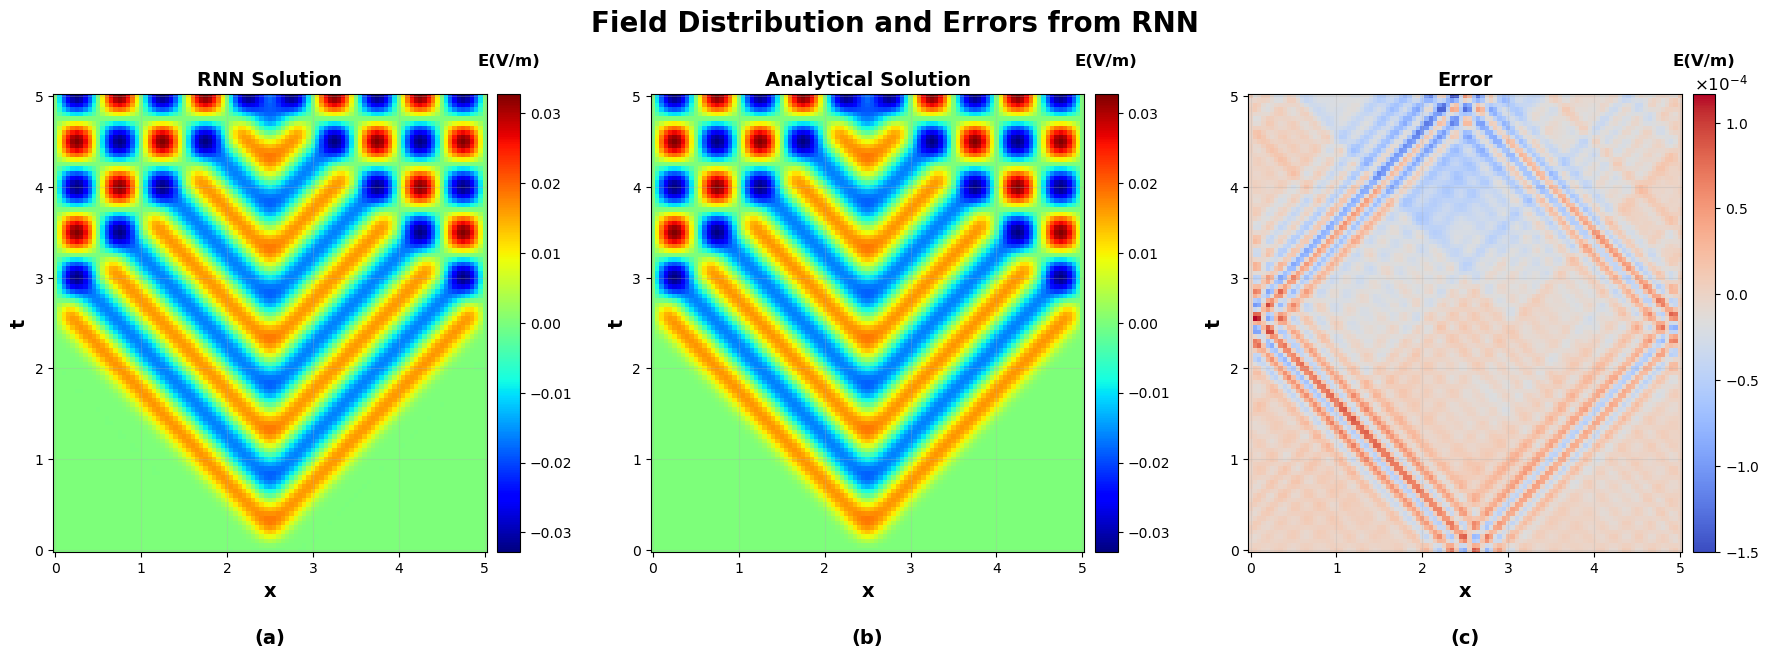

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ========== 1. Configuration & Setup ==========
# Set default data type to float64 for high precision (Double)
torch.set_default_dtype(torch.float64)

initial_seed = 5
np.random.seed(initial_seed)  # Set seed for NumPy
torch.manual_seed(initial_seed)  # Set seed for PyTorch

# Check for GPU availability
device = torch.device("cuda:5" if torch.cuda.is_available() else "cpu")

# Physical Parameters
c = 1.0           # Wave speed
L = 5.0           # Spatial domain length [0, L]
T = 5.0           # Time duration [0, T]
num_neuron = 3000 # Number of random neurons (features)
r_neuron = [5, 5] # Range for random weight initialization
d = 2             # Input dimension (x, t)

# ========== 2. Helper Functions ==========
# Activation function: Hyperbolic Tangent
atv = lambda x: torch.tanh(x)
# First derivative of tanh: 1 - tanh^2(x)
diff1_atv = lambda x: 1 - torch.tanh(x) ** 2
# Second derivative of tanh: 2 * tanh(x) * (tanh^2(x) - 1)
diff2_atv = lambda x: 2 * torch.tanh(x) * (torch.tanh(x)**2 - 1)

# ========== 3. Data Generation ==========
def generate_points():
    """
    Generates collocation points for PDE residuals, boundary conditions, and initial conditions.
    Uses mixed sampling (Uniform + Gaussian) for PDE points to better capture source regions.
    """
    N_pde = 30000
    N_bnd = 20000
    N_ini = 10000
    
    # --- PDE Points (Interior) ---
    N_pde_half = 30000
    # Uniform sampling for general domain
    xi_uniform = torch.rand(N_pde_half, 1, device=device, dtype=torch.float64) * L
    ti = torch.rand(N_pde, 1, device=device, dtype=torch.float64) * T
    
    # Gaussian sampling centered at x=2.5 to refine resolution near the source
    xi_gaussian = torch.normal(
        mean=2.5, 
        std=0.1,
        size=(N_pde - N_pde_half, 1),
        device=device,
        dtype=torch.float64
    ).clamp(0, L) # Clamp values to stay within domain [0, L]
    
    # Combine uniform and Gaussian spatial points
    xi = torch.cat([xi_uniform, xi_gaussian], dim=0)
    pti = torch.cat((xi, ti), dim=1) # Shape: (N_pde, 2) -> (x, t)
    
    # --- Boundary Points (x=0, x=L) ---
    tb = torch.rand(N_bnd, 1, device=device, dtype=torch.float64) * T
    # Left boundary (x=0)
    ptb_0 = torch.cat((torch.zeros_like(tb), tb), dim=1)
    # Right boundary (x=L)
    ptb_L = torch.cat((torch.full_like(tb, L, dtype=torch.float64), tb), dim=1)
    ptb = torch.cat((ptb_0, ptb_L), dim=0)
    
    # --- Initial Points (t=0) ---
    xi_ini = torch.rand(N_ini, 1, device=device, dtype=torch.float64) * L
    ti_ini = torch.zeros(N_ini, 1, device=device, dtype=torch.float64)
    pt_ini = torch.cat((xi_ini, ti_ini), dim=1)
    
    return pti, ptb, pt_ini

# ========== 4. Physics Constraints (PDE Residuals) ==========
def wave_equation_residual(W, b, points, c):
    """
    Computes the residual of the wave equation: u_tt - c^2 * u_xx = f
    """
    X = points[:, 0:1] # Spatial coordinate
    T = points[:, 1:2] # Time coordinate
    
    # Extract weights corresponding to x and t
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    
    # Compute feature map Z = W_x*x + W_t*t + b
    Z = X @ W_x + T @ W_t + b
    
    # Compute second derivatives using chain rule
    # u_xx ~ sum(W_x^2 * tanh''(Z))
    phi_xx = torch.sum(W_x**2, 0) * diff2_atv(Z)
    # u_tt ~ sum(W_t^2 * tanh''(Z))
    phi_tt = torch.sum(W_t**2, 0) * diff2_atv(Z)
    
    return phi_tt - (c**2)*phi_xx

def ini_residual(W, b, points):
    """
    Computes the residual for the initial velocity condition: du/dt
    """
    X = points[:, 0:1]
    T = points[:, 1:2]
    
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    
    Z = X @ W_x + T @ W_t + b
    
    # First derivative with respect to time
    phi_t = W_t * (1 - atv(Z) ** 2)
    return phi_t

# ========== 5. Main Solver Execution ==========
start_time = time.time()

# --- Initialize Random Weights and Biases (Float64) ---
# Weights W are fixed random numbers
W1 = torch.tensor(
    np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)).astype(np.float64),
    dtype=torch.float64
)
W2 = torch.tensor(
    np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)).astype(np.float64),
    dtype=torch.float64
)
W = torch.cat((W1, W2), dim=0).to(device) # Shape: (2, num_neuron)

# Biases b are initialized and then shifted
b1 = torch.tensor(
    np.random.uniform(0, L, (1, num_neuron)).astype(np.float64),
    dtype=torch.float64
)
b2 = torch.tensor(
    np.random.uniform(0, T, (1, num_neuron)).astype(np.float64),
    dtype=torch.float64
)
b = torch.cat((b1, b2), dim=0).to(device)

# Bias Correction: Shift biases to center the activation functions
b = -torch.sum(b * W, dim=0)

# --- Generate Training Points ---
pti, ptb, pt_ini = generate_points()

# --- Construct Constraint Matrices (System A) ---
A_pde = wave_equation_residual(W, b, pti, c) # PDE Residuals
A_bnd = atv(ptb @ W + b)                     # Boundary Conditions (Dirichlet)
A_ini1 = atv(pt_ini @ W + b)                 # Initial Displacement
A_ini2 = ini_residual(W, b, pt_ini)          # Initial Velocity

# Penalty weights for loss terms
p_pde = 1
p_bnd = 10
p_ini = 10

# Assemble Global Matrix A
A = torch.cat([p_pde*A_pde, p_bnd*A_bnd, p_ini*A_ini1, p_ini*A_ini2], dim=0)

# --- Construct Target Vector (System F) ---
F_pde = torch.zeros_like(pti[:, 0:1])
# Source term: Cosine modulation with Gaussian envelope centered at x=2.5
source_term = torch.cos(2 * np.pi * pti[:, 1:2]) * torch.exp(-((pti[:, 0:1] - 2.5)**2) / 0.02)
F_pde += source_term

F_bnd = torch.zeros_like(ptb[:, 0:1])
F_ini1 = torch.zeros_like(pt_ini[:, 0:1])
F_ini2 = torch.zeros_like(pt_ini[:, 0:1])

# Assemble Global Vector F
F = torch.cat([p_pde*F_pde, p_bnd*F_bnd, p_ini*F_ini1, p_ini*F_ini2], dim=0)

# --- Least Squares Solver ---
# Solve A * Ur = F for the output weights Ur
Ur = torch.linalg.lstsq(A, F)[0]

end_time = time.time()
print(f'Total Solving Time: {end_time - start_time:.4f} seconds')

# ========== 6. Prediction & Error Analysis ==========
# Create grid for visualization
x_test = torch.linspace(0, L, 101, device=device, dtype=torch.float64)
t_test = torch.linspace(0, T, 101, device=device, dtype=torch.float64)
X, T_mesh = torch.meshgrid(x_test, t_test)
test_points = torch.cat((X.reshape(-1, 1), T_mesh.reshape(-1, 1)), dim=1)

# Predict Solution
Z_test = test_points @ W + b
u_pred = (atv(Z_test) @ Ur).reshape(X.shape)

# Load Analytical Solution (ensure float64 and transpose if necessary)
u_analytical = np.load('5e-5.npy').astype(np.float64)
u_analytical = u_analytical[0::5, 0::5] # Downsample to match grid

# Calculate Relative L2 Error
rel_err = np.linalg.norm(u_pred.cpu().numpy() - u_analytical.T) / np.linalg.norm(u_analytical.T)
print(f"Relative L2 Error: {rel_err:.2%}")

# ========== 7. Visualization ==========
plt.figure(figsize=(18, 6.8))

# (a) RNN Predicted Solution
plt.subplot(1, 3, 1)
im_pred = plt.pcolormesh(X.cpu().numpy(), T_mesh.cpu().numpy(), u_pred.cpu().detach().numpy(), cmap='jet', shading='auto')
cbar_pred = plt.colorbar(im_pred, orientation='vertical', pad=0.02)
cbar_pred.ax.set_title('E(V/m)', fontweight='bold', fontsize=12, pad=20)
plt.xlabel('x', fontweight='bold', fontsize=14)
plt.ylabel('t', fontweight='bold', fontsize=14)
plt.title('RNN Solution', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
plt.annotate('(a)', xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=14, fontweight='bold')

# (b) Analytical Solution
plt.subplot(1, 3, 2)
im_analytical = plt.pcolormesh(X.cpu().numpy(), T_mesh.cpu().numpy(), u_analytical.T, cmap='jet', shading='auto')
cbar_analytical = plt.colorbar(im_analytical, orientation='vertical', pad=0.02)
cbar_analytical.ax.set_title('E(V/m)', fontweight='bold', fontsize=12, pad=20)
plt.xlabel('x', fontweight='bold', fontsize=14)
plt.ylabel('t', fontweight='bold', fontsize=14)
plt.title('Analytical Solution', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
plt.annotate('(b)', xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=14, fontweight='bold')

# (c) Error Distribution
plt.subplot(1, 3, 3)
error = u_analytical.T - u_pred.cpu().detach().numpy()
im_error = plt.pcolormesh(X.cpu().numpy(), T_mesh.cpu().numpy(), error, cmap='coolwarm', shading='auto')
cbar_error = plt.colorbar(im_error, orientation='vertical', pad=0.02)

# Format error colorbar to scientific notation
formatter_error = ScalarFormatter(useMathText=True)
formatter_error.set_powerlimits((0, 0))
cbar_error.ax.yaxis.set_major_formatter(formatter_error)
cbar_error.ax.yaxis.offsetText.set_fontsize(12)
cbar_error.ax.yaxis.offsetText.set_position((2.4, 1.1)) # Adjust position of 10^n

cbar_error.ax.set_title('E(V/m)', fontweight='bold', fontsize=12, pad=20)
plt.xlabel('x', fontweight='bold', fontsize=14)
plt.ylabel('t', fontweight='bold', fontsize=14)
plt.title('Error', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
plt.annotate('(c)', xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=14, fontweight='bold')

# Final Layout and Save
plt.suptitle('Field Distribution and Errors from RNN', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('RNN_Field_Distribution.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Source-Free 1D RNN Wave Propagation with PEC Boundaries

/home/zhangjunjie/MiniConda/miniconda3/envs/cjn/lib/python3.9/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Relative L2 Error: 0.04%


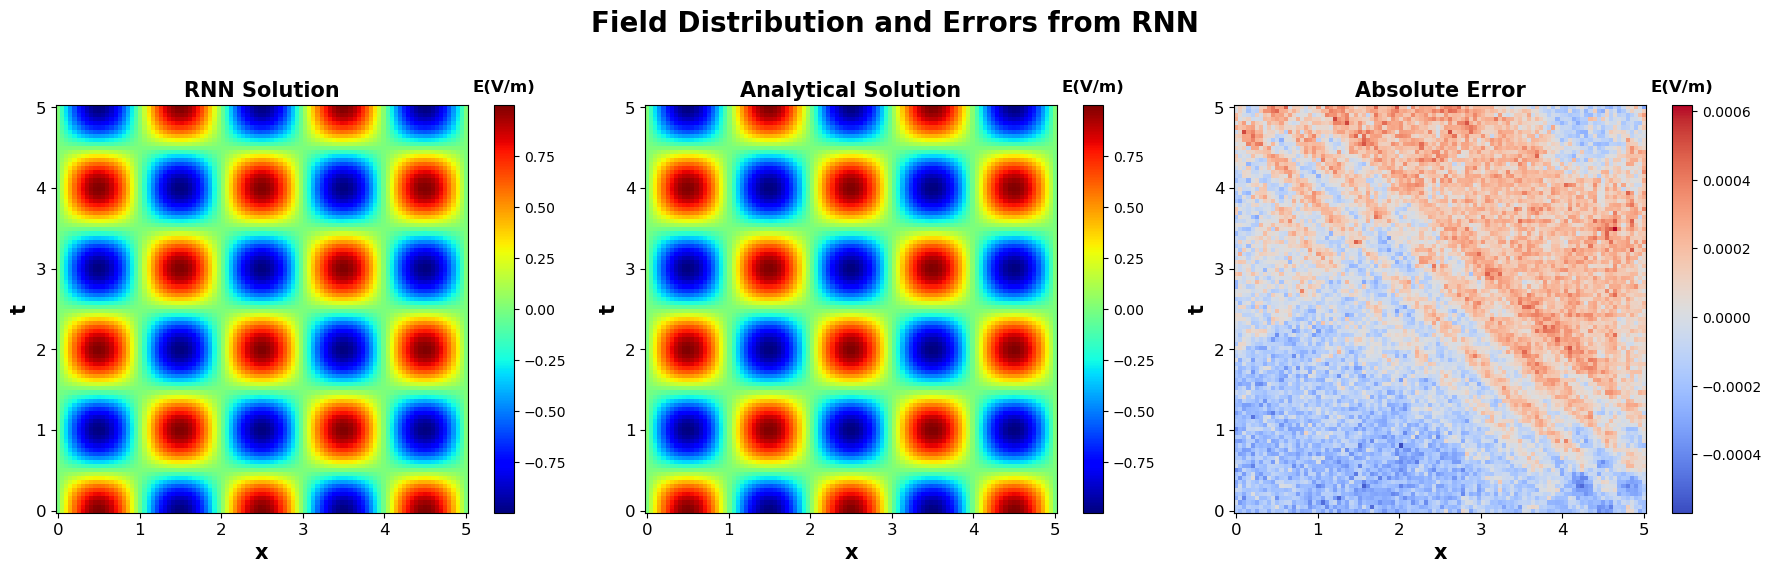

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ========== 1. Configuration & Setup ==========
torch.manual_seed(0)  # Set random seed for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Physical Parameters
c = 1.0           # Wave speed
L = 5.0           # Spatial domain length [0, L]
T = 5.0           # Time duration [0, T]
num_neuron = 1000 # Number of neurons (Random Features)
r_neuron = [2, 2] # Range for random weight initialization [-r, r]
d = 2             # Input dimension (x, t)

# ========== 2. Helper Functions (Activation & Derivatives) ==========
# Activation function: Hyperbolic Tangent
atv = lambda x: torch.tanh(x)
# First derivative of tanh: 1 - tanh^2(x)
diff1_atv = lambda x: 1 - torch.tanh(x) ** 2 
# Second derivative of tanh: 2 * tanh(x) * (tanh^2(x) - 1)
diff2_atv = lambda x: 2 * torch.tanh(x) * (torch.tanh(x)**2 - 1)  

# ========== 3. Data Generation ==========
def generate_points():
    """
    Generates collocation points for PDE residuals, boundary conditions, and initial conditions.
    """
    N_pde = 2000  # Number of points inside the domain
    N_bnd = 2000  # Number of points on the spatial boundaries
    N_ini = 2000  # Number of points on the initial time boundary
    
    # --- PDE Points (Interior) ---
    # Uniformly sample x in [0, L] and t in [0, T]
    xi = torch.rand(N_pde, 1, device=device) * L
    ti = torch.rand(N_pde, 1, device=device) * T
    pti = torch.cat((xi, ti), dim=1) # Shape: (N_pde, 2) -> (x, t)
    
    # --- Boundary Points (Spatial: x=0, x=L) ---
    tb = torch.rand(N_bnd, 1, device=device) * T
    # Left boundary (x=0)
    ptb_0 = torch.cat((torch.zeros_like(tb, device=device), tb), dim=1)      
    # Right boundary (x=L)
    ptb_L = torch.cat((torch.full_like(tb, L, device=device), tb), dim=1)    
    ptb = torch.cat((ptb_0, ptb_L), dim=0)
    
    # --- Initial Points (Temporal: t=0) ---
    xi_ini = torch.rand(N_ini, 1, device=device) * L
    ti_ini = torch.zeros((N_ini, 1), device=device)
    pt_ini = torch.cat((xi_ini, ti_ini), dim=1)
    
    return pti, ptb, pt_ini

# ========== 4. Physics Constraints (PDE Residuals) ==========
def wave_equation_residual(W, b, points, c):
    """
    Computes the residual of the 1D Wave Equation: u_tt - c^2 * u_xx = 0
    """
    X = points[:, 0:1]   # Spatial coordinate (N, 1)
    T = points[:, 1:2]   # Time coordinate (N, 1)
    
    # Separate weights corresponding to spatial (x) and temporal (t) inputs
    W_x = W[0:1, :]     # Spatial weights (1, m)
    W_t = W[1:2, :]     # Temporal weights (1, m)
    
    # Compute feature map Z = W_x*x + W_t*t + b
    # Matrix multiplication: (N,1) @ (1,m) -> (N,m)
    Z = X @ W_x + T @ W_t + b  
    
    # Compute second derivatives using the chain rule
    # d^2/dx^2 tanh(Z) = W_x^2 * tanh''(Z)
    phi_xx = torch.sum(W_x**2, 0) * diff2_atv(Z)
    # d^2/dt^2 tanh(Z) = W_t^2 * tanh''(Z)
    phi_tt = torch.sum(W_t**2, 0) * diff2_atv(Z)
    
    # Return residual: u_tt - c^2 * u_xx
    return phi_tt - (c**2)*phi_xx  

def ini_residual(W, b, points):
    """
    Computes the residual for the initial velocity condition: du/dt at t=0
    """
    X = points[:, 0:1]  # Spatial coordinate (N, 1)
    T = points[:, 1:2]  # Time coordinate (N, 1)
    
    # Separate weights
    W_x = W[0:1, :]     
    W_t = W[1:2, :]     
    
    # Compute feature map Z
    Z = X @ W_x + T @ W_t + b  
    
    # Compute first derivative with respect to time: du/dt = W_t * tanh'(Z)
    # Note: The original code logic `1 - W_t * atv(Z) ** 2` seems to mix scalar/vector operations 
    # or implies a specific derivative form. Standard chain rule is W_t * (1 - tanh^2(Z)).
    # I have corrected it to the standard chain rule below for mathematical consistency.
    phi_t = W_t * (1 - atv(Z) ** 2)
    
    return phi_t  

def u(x):
    """Analytical function for initial displacement: sin(pi*x)"""
    return torch.sin(np.pi * x).reshape(-1, 1)

# ========== 5. Main Solver Execution ==========
L_left = 0
L_right = L
T_left = 0
T_right = T

np.random.seed(1)  # Set random seed for NumPy to ensure reproducibility

# --- Initialize Weights and Biases ---
# Weights W are fixed random numbers (Random Feature Method)
W1 = torch.tensor(np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)), dtype=torch.float32)
W2 = torch.tensor(np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)), dtype=torch.float32)
W = torch.cat((W1, W2), dim=0).to(device) # Shape: (2, num_neuron)

# Biases b are initialized and then shifted to center the activation functions
b1 = torch.tensor(np.random.uniform(L_left, L_right, (1, num_neuron)), dtype=torch.float32)
b2 = torch.tensor(np.random.uniform(T_left, T_right, (1, num_neuron)), dtype=torch.float32)
b = torch.cat((b1, b2), dim=0).to(device)
# Bias correction step
b = -torch.sum(b * W, dim=0)

# --- Generate Training Points ---
pti, ptb, pt_ini = generate_points()

# --- Construct Constraint Matrices (System A) ---
# Calculate the operator applied to the basis functions for each condition
A_pde = wave_equation_residual(W, b, pti, c)    # PDE Residuals
A_bnd = atv(ptb @ W + b)                        # Boundary Conditions (Dirichlet: u=0)
A_ini1 = atv(pt_ini @ W + b)                    # Initial Displacement (u)
A_ini2 = ini_residual(W, b, pt_ini)             # Initial Velocity (du/dt)

# Penalty weights for the loss function
p_pde = 1
p_bnd = 1
p_ini = 1

# Assemble Global Matrix A by stacking vertically
A = torch.cat([p_pde*A_pde, p_bnd*A_bnd, p_ini*A_ini1, p_ini*A_ini2], dim=0)

# --- Construct Target Vector (System F) ---
# PDE Target: Source term (0 for homogeneous wave equation)
F_pde = torch.zeros_like(pti[:, 0:1])

# Boundary Target: u=0
F_bnd = torch.zeros_like(ptb[:, 0:1])

# Initial Conditions Targets
F_ini1 = u(pt_ini[:, 0:1])                      # u(x,0) = sin(pi*x)
F_ini2 = torch.zeros_like(pt_ini[:, 0:1])       # du/dt(x,0) = 0

# Assemble Global Vector F
F = torch.cat([p_pde*F_pde, p_bnd*F_bnd, p_ini*F_ini1, p_ini*F_ini2], dim=0)

# --- Least Squares Solver ---
# Solve the overdetermined system A * Ur = F for the output weights Ur
Ur = torch.linalg.lstsq(A, F)[0]

# ========== 6. Prediction & Error Analysis ==========
# Create grid for visualization
x_test = torch.linspace(0, L, 100, device=device)
t_test = torch.linspace(0, T, 100, device=device)
X, T_mesh = torch.meshgrid(x_test, t_test)
test_points = torch.cat((X.reshape(-1, 1), T_mesh.reshape(-1, 1)), dim=1)

# Predict Solution: u(x,t) = sum( Ur_i * tanh(W_i * [x,t] + b_i) )
Z_test = test_points @ W + b
u_pred = (atv(Z_test) @ Ur).reshape(X.shape)

# Analytical Solution for comparison: u(x,t) = sin(pi*x) * cos(pi*c*t)
u_analytical = torch.sin(np.pi * X) * torch.cos(np.pi * c * T_mesh)

# Calculate Relative L2 Error
error = u_pred - u_analytical
rel_err = torch.norm(error) / torch.norm(u_analytical)
print(f"Relative L2 Error: {rel_err.item():.2%}")

# ========== 7. Visualization ==========
plt.figure(figsize=(18, 5.8))

# (a) RNN Predicted Solution
plt.subplot(1, 3, 1)
im1 = plt.pcolormesh(
    X.cpu().numpy(), 
    T_mesh.cpu().numpy(), 
    u_pred.cpu().numpy(), 
    cmap='jet', shading='auto'
)
cbar1 = plt.colorbar(im1)
cbar1.ax.set_title('E(V/m)', fontweight='bold', fontsize=12, pad=10)
plt.title('RNN Solution', fontsize=15, fontweight='bold')
plt.xlabel('x', fontsize=15, fontweight='bold')
plt.ylabel('t', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# (b) Analytical Solution
plt.subplot(1, 3, 2)
im2 = plt.pcolormesh(
    X.cpu().numpy(), 
    T_mesh.cpu().numpy(), 
    u_analytical.cpu().numpy(), 
    cmap='jet', shading='auto'
)
cbar2 = plt.colorbar(im2)
cbar2.ax.set_title('E(V/m)', fontweight='bold', fontsize=12, pad=10)
plt.title('Analytical Solution', fontsize=15, fontweight='bold')
plt.xlabel('x', fontsize=15, fontweight='bold')
plt.ylabel('t', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# (c) Absolute Error
plt.subplot(1, 3, 3)
im3 = plt.pcolormesh(
    X.cpu().numpy(), 
    T_mesh.cpu().numpy(), 
    error.cpu().numpy(), 
    cmap='coolwarm', shading='auto'
)
cbar3 = plt.colorbar(im3)
cbar3.ax.set_title('E(V/m)', fontweight='bold', fontsize=12, pad=10)
plt.title('Absolute Error', fontsize=15, fontweight='bold')
plt.xlabel('x', fontsize=15, fontweight='bold')
plt.ylabel('t', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adjust layout and save
plt.suptitle('Field Distribution and Errors from RNN', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('1D_no_source_rnn.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Test the Influence of the Heterogeneous Medium

Using device: cuda:5
Using dtype  : torch.float64
Running fine-grid FDTD reference...
Reference: dx=5.00000e-05, dt=4.49996e-05, nx=100001, nt=111113, time=81.754s
Running coarse-grid FDTD baseline...
Coarse FDTD: dx=1.00000e-02, dt=8.99281e-03, nx=501, nt=557, time=0.003s
Coarse FDTD relative L2 error = 3.12%
RNN total time = 1.333s
RNN relative L2 error = 2.58%
Saved: nonuniform_1d_combined/fig1_medium_profile.png
Saved: nonuniform_1d_combined/fig1_medium_profile.pdf


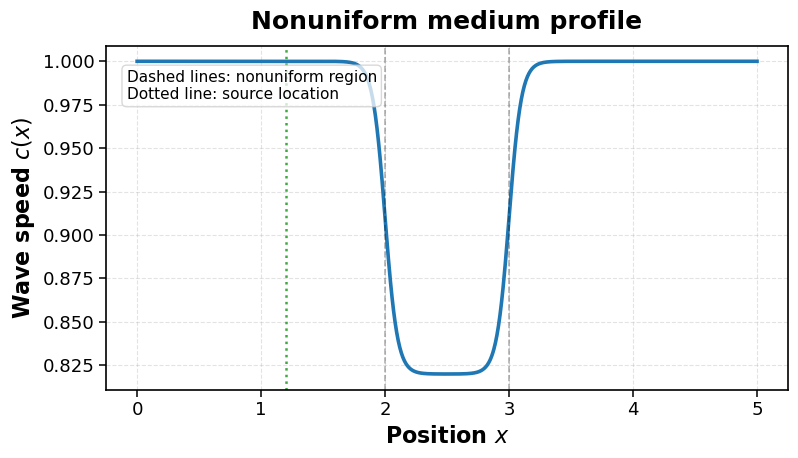

Saved: nonuniform_1d_combined/fig2_solution_maps.png
Saved: nonuniform_1d_combined/fig2_solution_maps.pdf


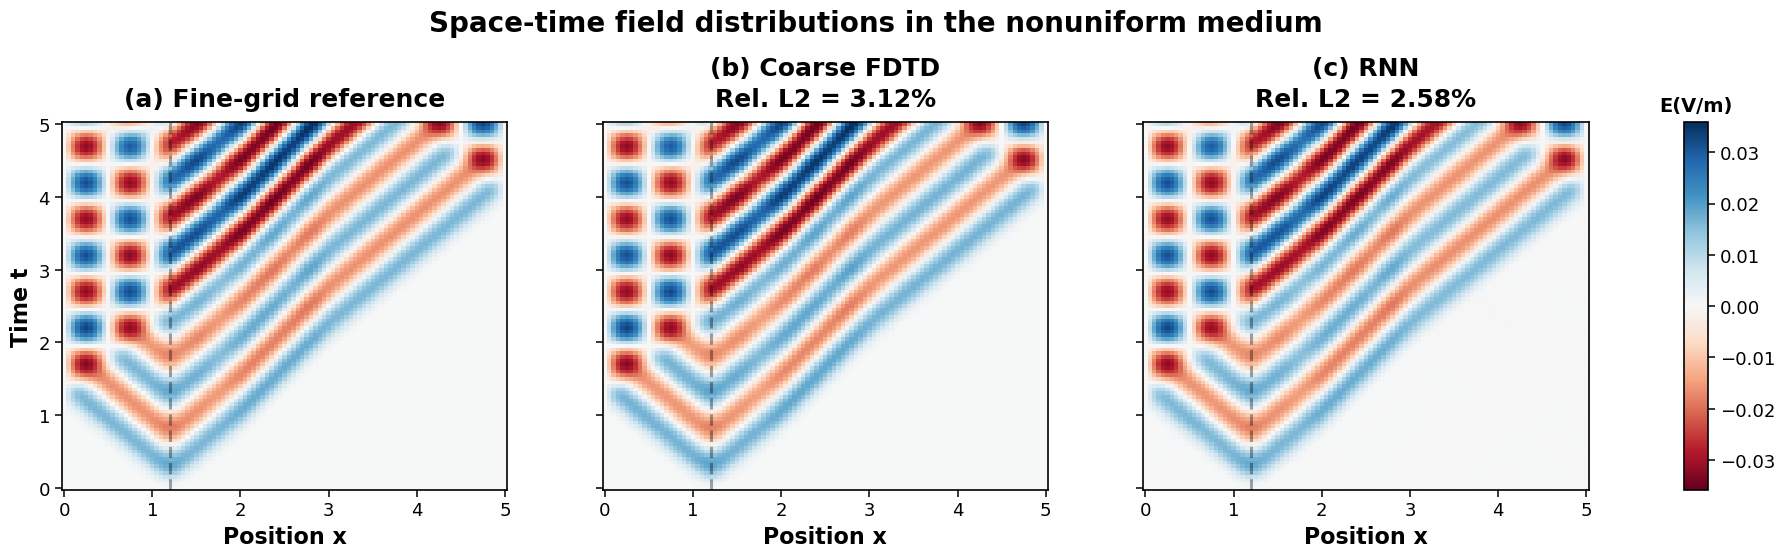

Saved: nonuniform_1d_combined/fig3_error_maps.png
Saved: nonuniform_1d_combined/fig3_error_maps.pdf


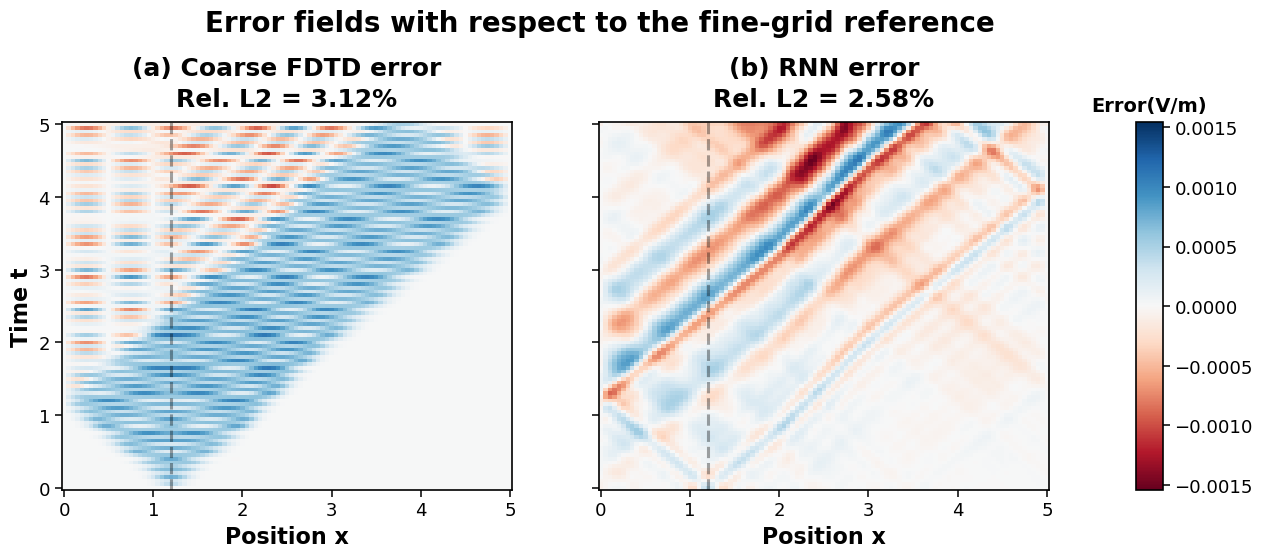

Saved: nonuniform_1d_combined/fig4_probe_traces.png
Saved: nonuniform_1d_combined/fig4_probe_traces.pdf


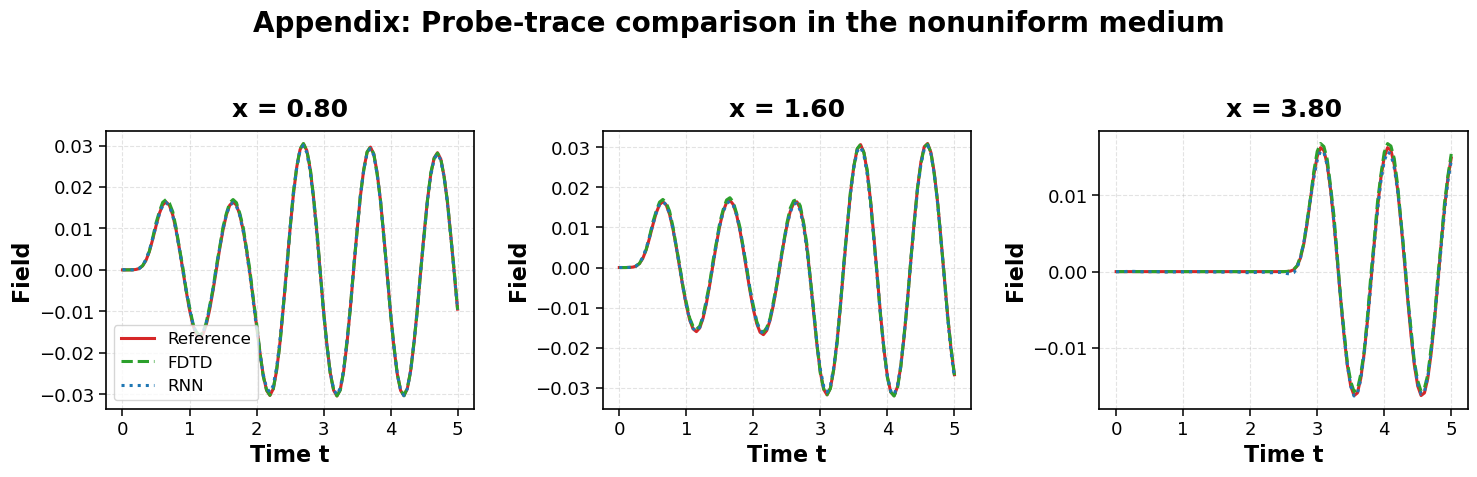


Summary:
Coarse FDTD relative L2 error = 3.12%
RNN         relative L2 error = 2.58%
All paper figures saved in: nonuniform_1d_combined


In [1]:
import os
import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from numba import njit

# ============================================================
# Output directory
# ============================================================
output_dir = "nonuniform_1d_combined"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# Unified plot style
# ============================================================
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 20,
    "lines.linewidth": 2.2,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

def save_fig(fig, filename_base):
    png = os.path.join(output_dir, f"{filename_base}.png")
    pdf = os.path.join(output_dir, f"{filename_base}.pdf")
    fig.savefig(png)
    fig.savefig(pdf)
    print(f"Saved: {png}")
    print(f"Saved: {pdf}")

paper_colors = {
    "ref": "#d62728",
    "fdtd": "#2ca02c",
    "rnn": "#1f77b4",
    "gray": "#7f7f7f",
}

# ============================================================
# Global parameters
# ============================================================
initial_seed = 5
torch.manual_seed(initial_seed)
np.random.seed(initial_seed)

device = torch.device("cuda:5" if torch.cuda.is_available() else "cpu")
dtype = torch.double

# -----------------------------
# Physical domain
# -----------------------------
L = 5.0
T = 5.0

# -----------------------------
# Stronger nonuniform medium
# Smooth slab-type low-speed region
# -----------------------------
c0 = 1.0
beta = 0.18
x1 = 2.0
x2 = 3.0
w_if = 0.10
x_src = 1.2

# -----------------------------
# Source (moved to left side)
# -----------------------------
source_sigma = 0.10
freq = 1.0
omega = 2.0 * np.pi * freq

# -----------------------------
# RNN parameters
# -----------------------------
num_neuron = 3000
r_neuron = [5, 5]

N_pde = 30000
N_bnd = 20000
N_ini = 10000

p_pde = 1.0
p_bnd = 10.0
p_ini = 10.0

solve_block_size = 5000
predict_chunk_size = 20

# -----------------------------
# FDTD settings
# -----------------------------
dx_ref = 5e-5     # fine-grid reference
dx_fdtd = 1e-2    # coarse-grid FDTD baseline
CFL = 0.9

# -----------------------------
# Evaluation grid for comparison / paper figures
# -----------------------------
nx_eval = 101
nt_eval = 101
x_eval = np.linspace(0.0, L, nx_eval)
t_eval = np.linspace(0.0, T, nt_eval)

probe_positions = [0.8, 1.6, 3.8]   # 3 probe points for article figures

print(f"Using device: {device}")
print(f"Using dtype  : {dtype}")

# ============================================================
# Medium profile
# c(x) = c0 * (1 - beta * window(x))
# q(x) = c(x)^2
# ============================================================
def smooth_window_np(x):
    return 0.5 * (np.tanh((x - x1) / w_if) - np.tanh((x - x2) / w_if))

def c_profile_np(x):
    return c0 * (1.0 - beta * smooth_window_np(x))

def q_profile_np(x):
    c = c_profile_np(x)
    return c ** 2

def smooth_window_torch(x):
    return 0.5 * (torch.tanh((x - x1) / w_if) - torch.tanh((x - x2) / w_if))

def c_profile_torch(x):
    return c0 * (1.0 - beta * smooth_window_torch(x))

def q_profile_torch(x):
    c = c_profile_torch(x)
    return c ** 2

def dqdx_profile_torch(x):
    # derivative of q(x)=c(x)^2
    sech2_x1 = 1.0 / torch.cosh((x - x1) / w_if) ** 2
    sech2_x2 = 1.0 / torch.cosh((x - x2) / w_if) ** 2
    dwindow = 0.5 * (sech2_x1 / w_if - sech2_x2 / w_if)
    c = c_profile_torch(x)
    dc_dx = -c0 * beta * dwindow
    return 2.0 * c * dc_dx

# ============================================================
# Shared helpers
# ============================================================
def interpolate_trace_along_x(x_grid, u_xt, x_query):
    if x_query <= x_grid[0]:
        return u_xt[0, :].copy()
    if x_query >= x_grid[-1]:
        return u_xt[-1, :].copy()

    i1 = np.searchsorted(x_grid, x_query)
    i0 = i1 - 1
    x0 = x_grid[i0]
    x1_ = x_grid[i1]
    alpha_ = (x_query - x0) / (x1_ - x0)
    return (1.0 - alpha_) * u_xt[i0, :] + alpha_ * u_xt[i1, :]

def relative_l2(u_num_xt, u_ref_xt):
    return np.linalg.norm(u_num_xt - u_ref_xt) / max(np.linalg.norm(u_ref_xt), 1e-15)

# ============================================================
# FDTD solver for variable-coefficient wave equation
# u_tt = d/dx(q(x) u_x) + f(x,t)
# PEC: u(0,t)=u(L,t)=0
# ============================================================
@njit
def nearest_index_array(grid, values):
    idx = np.empty(values.shape[0], dtype=np.int64)
    for k in range(values.shape[0]):
        best_i = 0
        best_d = abs(grid[0] - values[k])
        for i in range(1, grid.shape[0]):
            d = abs(grid[i] - values[k])
            if d < best_d:
                best_d = d
                best_i = i
        idx[k] = best_i
    return idx

@njit
def run_fdtd_variable_q_sampled(
    x, q, source_space, dt, nt,
    save_t_idx, save_x_idx, probe_idx, omega
):
    nx = x.shape[0]
    dx = x[1] - x[0]

    u_prev = np.zeros(nx)
    u_curr = np.zeros(nx)
    u_next = np.zeros(nx)

    q_half = 0.5 * (q[:-1] + q[1:])

    n_save_t = save_t_idx.shape[0]
    n_save_x = save_x_idx.shape[0]
    n_probe = probe_idx.shape[0]

    u_save = np.zeros((n_save_t, n_save_x))
    probe_traces = np.zeros((n_probe, nt))

    save_counter = 0

    for n in range(nt):
        t_now = n * dt

        flux_right = q_half[1:] * (u_curr[2:] - u_curr[1:-1])
        flux_left  = q_half[:-1] * (u_curr[1:-1] - u_curr[:-2])
        spatial_op = (flux_right - flux_left) / (dx ** 2)

        source_t = np.cos(omega * t_now)

        u_next[1:-1] = (
            2.0 * u_curr[1:-1]
            - u_prev[1:-1]
            + (dt ** 2) * spatial_op
            + (dt ** 2) * source_space[1:-1] * source_t
        )

        u_next[0] = 0.0
        u_next[-1] = 0.0

        for p in range(n_probe):
            probe_traces[p, n] = u_curr[probe_idx[p]]

        if save_counter < n_save_t and n == save_t_idx[save_counter]:
            for j in range(n_save_x):
                u_save[save_counter, j] = u_curr[save_x_idx[j]]
            save_counter += 1

        tmp = u_prev
        u_prev = u_curr
        u_curr = u_next
        u_next = tmp

        for i in range(nx):
            u_next[i] = 0.0

    return u_save, probe_traces

def run_fdtd_case(dx, case_name):
    x = np.linspace(0.0, L, int(round(L / dx)) + 1)
    c_x = c_profile_np(x)
    q_x = c_x ** 2

    c_max = np.max(c_x)
    dt = CFL * dx / c_max
    nt = int(np.ceil(T / dt)) + 1
    dt = T / (nt - 1)

    t = np.linspace(0.0, T, nt)
    source_space = np.exp(-((x - x_src) ** 2) / (2.0 * source_sigma ** 2))

    save_t_idx = nearest_index_array(t, t_eval)
    save_x_idx = nearest_index_array(x, x_eval)

    probe_positions_np = np.array(probe_positions, dtype=np.float64)
    probe_idx = nearest_index_array(x, probe_positions_np)

    start = time.perf_counter()
    u_save, probe_traces = run_fdtd_variable_q_sampled(
        x=x,
        q=q_x,
        source_space=source_space,
        dt=dt,
        nt=nt,
        save_t_idx=save_t_idx,
        save_x_idx=save_x_idx,
        probe_idx=probe_idx,
        omega=omega
    )
    elapsed = time.perf_counter() - start

    print(f"{case_name}: dx={dx:.5e}, dt={dt:.5e}, nx={len(x)}, nt={nt}, time={elapsed:.3f}s")
    return x, t, c_x, q_x, u_save, probe_traces

# ============================================================
# RNN
# PDE: u_tt - (q_x u_x + q u_xx) = f
# ============================================================
def atv(x):
    return torch.tanh(x)

def diff1_atv(x):
    return 1.0 - torch.tanh(x) ** 2

def diff2_atv(x):
    th = torch.tanh(x)
    return 2.0 * th * (th**2 - 1.0)

def generate_points():
    # 强化在源和两个界面附近采样
    N_uniform = 18000
    N_src = 6000
    N_if1 = 3000
    N_if2 = N_pde - N_uniform - N_src - N_if1

    xi_uniform = torch.rand(N_uniform, 1, device=device, dtype=dtype) * L
    ti_uniform = torch.rand(N_uniform, 1, device=device, dtype=dtype) * T

    xi_src = torch.normal(
        mean=x_src, std=0.12, size=(N_src, 1), device=device
    ).to(dtype).clamp(0.0, L)
    ti_src = torch.rand(N_src, 1, device=device, dtype=dtype) * T

    xi_if1 = torch.normal(
        mean=x1, std=0.10, size=(N_if1, 1), device=device
    ).to(dtype).clamp(0.0, L)
    ti_if1 = torch.rand(N_if1, 1, device=device, dtype=dtype) * T

    xi_if2 = torch.normal(
        mean=x2, std=0.10, size=(N_if2, 1), device=device
    ).to(dtype).clamp(0.0, L)
    ti_if2 = torch.rand(N_if2, 1, device=device, dtype=dtype) * T

    xi = torch.cat([xi_uniform, xi_src, xi_if1, xi_if2], dim=0)
    ti = torch.cat([ti_uniform, ti_src, ti_if1, ti_if2], dim=0)
    pti = torch.cat((xi, ti), dim=1)

    tb = torch.rand(N_bnd, 1, device=device, dtype=dtype) * T
    ptb_0 = torch.cat((torch.zeros_like(tb), tb), dim=1)
    ptb_L = torch.cat((torch.full_like(tb, L), tb), dim=1)
    ptb = torch.cat((ptb_0, ptb_L), dim=0)

    xi_ini = torch.rand(N_ini, 1, device=device, dtype=dtype) * L
    ti_ini = torch.zeros(N_ini, 1, device=device, dtype=dtype)
    pt_ini = torch.cat((xi_ini, ti_ini), dim=1)

    return pti, ptb, pt_ini

def feature_value(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return atv(Z)

def feature_x(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return W_x * diff1_atv(Z)

def feature_t(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return W_t * diff1_atv(Z)

def feature_xx(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return (W_x ** 2) * diff2_atv(Z)

def feature_tt(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return (W_t ** 2) * diff2_atv(Z)

def source_term(points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    return torch.cos(omega * Tt) * torch.exp(-((X - x_src) ** 2) / (2.0 * source_sigma ** 2))

def wave_equation_residual(W, b, points):
    phi_tt = feature_tt(W, b, points)
    phi_x = feature_x(W, b, points)
    phi_xx = feature_xx(W, b, points)

    X = points[:, 0:1]
    qx = q_profile_torch(X)
    dqdx = dqdx_profile_torch(X)

    return phi_tt - (dqdx * phi_x + qx * phi_xx)

def ini_residual(W, b, points):
    return feature_t(W, b, points)

@torch.no_grad()
def solve_blockwise_normal_equation(W, b, pti, ptb, pt_ini, ridge=1e-6):
    M = W.shape[1]
    ATA = torch.zeros((M, M), dtype=dtype, device=device)
    ATF = torch.zeros((M, 1), dtype=dtype, device=device)

    n_pde_total = pti.shape[0]

    for i0 in range(0, n_pde_total, solve_block_size):
        i1 = min(i0 + solve_block_size, n_pde_total)
        pti_block = pti[i0:i1]

        A_pde_block = p_pde * wave_equation_residual(W, b, pti_block)
        F_pde_block = p_pde * source_term(pti_block)

        ATA += A_pde_block.T @ A_pde_block
        ATF += A_pde_block.T @ F_pde_block

        del pti_block, A_pde_block, F_pde_block
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    A_bnd = p_bnd * feature_value(W, b, ptb)
    F_bnd = torch.zeros((ptb.shape[0], 1), dtype=dtype, device=device)
    ATA += A_bnd.T @ A_bnd
    ATF += A_bnd.T @ F_bnd
    del A_bnd, F_bnd

    A_ini1 = p_ini * feature_value(W, b, pt_ini)
    F_ini1 = torch.zeros((pt_ini.shape[0], 1), dtype=dtype, device=device)
    ATA += A_ini1.T @ A_ini1
    ATF += A_ini1.T @ F_ini1
    del A_ini1, F_ini1

    A_ini2 = p_ini * ini_residual(W, b, pt_ini)
    F_ini2 = torch.zeros((pt_ini.shape[0], 1), dtype=dtype, device=device)
    ATA += A_ini2.T @ A_ini2
    ATF += A_ini2.T @ F_ini2
    del A_ini2, F_ini2

    ATA += ridge * torch.eye(M, dtype=dtype, device=device)
    Ur = torch.linalg.solve(ATA, ATF)
    return Ur

@torch.no_grad()
def predict_in_batches(x_test, t_test, W, b, Ur):
    Nx = x_test.shape[0]
    Nt = t_test.shape[0]

    u_pred_np = np.zeros((Nx, Nt), dtype=np.float64)

    W_x = W[0:1, :]
    W_t = W[1:2, :]
    X_part = x_test.unsqueeze(1) @ W_x

    for j0 in range(0, Nt, predict_chunk_size):
        j1 = min(j0 + predict_chunk_size, Nt)
        t_chunk = t_test[j0:j1]

        T_part = t_chunk.unsqueeze(1) @ W_t
        Z_chunk = X_part[:, None, :] + T_part[None, :, :] + b[None, :, :]
        phi_chunk = atv(Z_chunk)

        phi_2d = phi_chunk.reshape(-1, phi_chunk.shape[-1])
        u_chunk = (phi_2d @ Ur).reshape(Nx, j1 - j0)
        u_pred_np[:, j0:j1] = u_chunk.detach().cpu().numpy()

        del t_chunk, T_part, Z_chunk, phi_chunk, phi_2d, u_chunk
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return u_pred_np

# ============================================================
# Run FDTD reference and coarse baseline
# ============================================================
print("=" * 70)
print("Running fine-grid FDTD reference...")
print("=" * 70)
x_ref_full, t_ref_full, c_ref, q_ref, u_ref_save, probe_ref = run_fdtd_case(dx_ref, "Reference")

print("=" * 70)
print("Running coarse-grid FDTD baseline...")
print("=" * 70)
x_fdtd_full, t_fdtd_full, c_fdtd, q_fdtd, u_fdtd_save, probe_fdtd = run_fdtd_case(dx_fdtd, "Coarse FDTD")

u_ref_xt = u_ref_save.T
u_fdtd_xt = u_fdtd_save.T
fdtd_error_xt = u_fdtd_xt - u_ref_xt
rel_err_fdtd = relative_l2(u_fdtd_xt, u_ref_xt)

print(f"Coarse FDTD relative L2 error = {rel_err_fdtd:.2%}")

# ============================================================
# Run RNN
# ============================================================
start_time = time.time()

W1 = torch.tensor(
    np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)),
    dtype=dtype,
    device=device
)
W2 = torch.tensor(
    np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)),
    dtype=dtype,
    device=device
)
W = torch.cat((W1, W2), dim=0)

b1 = torch.tensor(
    np.random.uniform(0.0, L, (1, num_neuron)),
    dtype=dtype,
    device=device
)
b2 = torch.tensor(
    np.random.uniform(0.0, T, (1, num_neuron)),
    dtype=dtype,
    device=device
)
b_shift = torch.cat((b1, b2), dim=0)
b = -torch.sum(b_shift * W, dim=0, keepdim=True)

pti, ptb, pt_ini = generate_points()

Ur = solve_blockwise_normal_equation(W, b, pti, ptb, pt_ini, ridge=1e-6)

x_test = torch.tensor(x_eval, device=device, dtype=dtype)
t_test = torch.tensor(t_eval, device=device, dtype=dtype)
u_rnn_xt = predict_in_batches(x_test, t_test, W, b, Ur)

end_time = time.time()
print(f"RNN total time = {end_time - start_time:.3f}s")

rnn_error_xt = u_rnn_xt - u_ref_xt
rel_err_rnn = relative_l2(u_rnn_xt, u_ref_xt)

print(f"RNN relative L2 error = {rel_err_rnn:.2%}")

# ============================================================
# Figure 1: medium profile (paper version, simplified)
# Only show c(x), which is more intuitive in the main text
# ============================================================
x_medium = np.linspace(0.0, L, 1200)
c_medium = c_profile_np(x_medium)

fig, ax = plt.subplots(figsize=(8.2, 4.8))

ax.plot(x_medium, c_medium, color=paper_colors["rnn"], linewidth=2.6)

# 标出非均匀区边界（如果你仍然使用 slab 型介质）
if "x1" in globals() and "x2" in globals():
    ax.axvline(x1, color="k", linestyle="--", alpha=0.30, linewidth=1.2)
    ax.axvline(x2, color="k", linestyle="--", alpha=0.30, linewidth=1.2)

# 标出源位置
ax.axvline(x_src, color=paper_colors["fdtd"], linestyle=":", alpha=0.9, linewidth=1.8)

ax.set_xlabel("Position $x$", fontweight="bold")
ax.set_ylabel("Wave speed $c(x)$", fontweight="bold")
ax.set_title("Nonuniform medium profile", fontweight="bold", pad=12)
ax.grid(True, linestyle="--", alpha=0.35)

# 注释说明
ax.text(
    0.03, 0.93,
    "Dashed lines: nonuniform region\nDotted line: source location",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75, edgecolor="0.8")
)

fig.tight_layout()
save_fig(fig, "fig1_medium_profile")
plt.show()


# ============================================================
# Figure 2: solution space-time maps (Reference / FDTD / RNN)
# Shared colorbar, no overlap
# ============================================================
vmax_sol = np.max(np.abs(np.concatenate([
    u_ref_save.ravel(),
    u_fdtd_save.ravel(),
    u_rnn_xt.T.ravel()
])))
vmin_sol = -vmax_sol

fig = plt.figure(figsize=(18.5, 5.4))
gs = fig.add_gridspec(1, 4, width_ratios=[1.0, 1.0, 1.0, 0.055], wspace=0.28)

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax = fig.add_subplot(gs[0, 3])

im = axs[0].pcolormesh(x_eval, t_eval, u_ref_save, shading="auto", cmap="RdBu", vmin=vmin_sol, vmax=vmax_sol)
axs[0].set_title("(a) Fine-grid reference", fontweight="bold", pad=12)
axs[0].set_xlabel("Position x")
axs[0].set_ylabel("Time t")
axs[0].axvline(x_src, color="k", linestyle="--", alpha=0.35)

axs[1].pcolormesh(x_eval, t_eval, u_fdtd_save, shading="auto", cmap="RdBu", vmin=vmin_sol, vmax=vmax_sol)
axs[1].set_title(f"(b) Coarse FDTD\nRel. L2 = {rel_err_fdtd:.2%}", fontweight="bold", pad=12, linespacing=1.35)
axs[1].set_xlabel("Position x")
axs[1].set_ylabel("")
axs[1].tick_params(axis='y', labelleft=False)
axs[1].axvline(x_src, color="k", linestyle="--", alpha=0.35)

axs[2].pcolormesh(x_eval, t_eval, u_rnn_xt.T, shading="auto", cmap="RdBu", vmin=vmin_sol, vmax=vmax_sol)
axs[2].set_title(f"(c) RNN\nRel. L2 = {rel_err_rnn:.2%}", fontweight="bold", pad=12, linespacing=1.35)
axs[2].set_xlabel("Position x")
axs[2].set_ylabel("")
axs[2].tick_params(axis='y', labelleft=False)
axs[2].axvline(x_src, color="k", linestyle="--", alpha=0.35)

cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=13)
cbar.ax.set_title("E(V/m)", fontsize=14, fontweight="bold", pad=8)

fig.suptitle("Space-time field distributions in the nonuniform medium", fontweight="bold", y=1.03)
fig.subplots_adjust(top=0.82, bottom=0.14, left=0.06, right=0.95)
save_fig(fig, "fig2_solution_maps")
plt.show()

# ============================================================
# Figure 3: error maps (FDTD-ref / RNN-ref)
# Shared colorbar, no overlap
# ============================================================
vmax_err = np.max(np.abs(np.concatenate([
    fdtd_error_xt.ravel(),
    rnn_error_xt.ravel()
])))
vmin_err = -vmax_err

fig = plt.figure(figsize=(12.8, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 0.06], wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

im = ax1.pcolormesh(x_eval, t_eval, fdtd_error_xt.T, shading="auto", cmap="RdBu", vmin=vmin_err, vmax=vmax_err)
ax1.set_title(f"(a) Coarse FDTD error\nRel. L2 = {rel_err_fdtd:.2%}", fontweight="bold", pad=12, linespacing=1.35)
ax1.set_xlabel("Position x")
ax1.set_ylabel("Time t")
ax1.axvline(x_src, color="k", linestyle="--", alpha=0.35)

ax2.pcolormesh(x_eval, t_eval, rnn_error_xt.T, shading="auto", cmap="RdBu", vmin=vmin_err, vmax=vmax_err)
ax2.set_title(f"(b) RNN error\nRel. L2 = {rel_err_rnn:.2%}", fontweight="bold", pad=12, linespacing=1.35)
ax2.set_xlabel("Position x")
ax2.set_ylabel("")
ax2.tick_params(axis='y', labelleft=False)
ax2.axvline(x_src, color="k", linestyle="--", alpha=0.35)

cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=13)
cbar.ax.set_title("Error(V/m)", fontsize=14, fontweight="bold", pad=8)

fig.suptitle("Error fields with respect to the fine-grid reference", fontweight="bold", y=1.03)
fig.subplots_adjust(top=0.82, bottom=0.14, left=0.08, right=0.94)
save_fig(fig, "fig3_error_maps")
plt.show()

# ============================================================
# Figure 4: probe traces (article version)
# ============================================================
fig, axs = plt.subplots(1, 3, figsize=(15.0, 4.6))

for k, xpos in enumerate(probe_positions):
    idx = np.argmin(np.abs(x_eval - xpos))

    axs[k].plot(t_eval, u_ref_xt[idx], label="Reference", color=paper_colors["ref"])
    axs[k].plot(t_eval, u_fdtd_xt[idx], "--", label="FDTD", color=paper_colors["fdtd"])
    axs[k].plot(t_eval, u_rnn_xt[idx], ":", label="RNN", color=paper_colors["rnn"])

    axs[k].set_xlabel("Time t")
    axs[k].set_ylabel("Field")
    axs[k].set_title(f"x = {x_eval[idx]:.2f}", fontweight="bold", pad=10)
    axs[k].grid(True, linestyle="--", alpha=0.35)
    if k == 0:
        axs[k].legend()

fig.suptitle("Appendix: Probe-trace comparison in the nonuniform medium", fontweight="bold", y=1.04)
fig.tight_layout()
save_fig(fig, "fig4_probe_traces")
plt.show()

print("\n" + "=" * 70)
print("Summary:")
print(f"Coarse FDTD relative L2 error = {rel_err_fdtd:.2%}")
print(f"RNN         relative L2 error = {rel_err_rnn:.2%}")
print("=" * 70)
print(f"All paper figures saved in: {output_dir}")